In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv("Social_Network_Ads.csv")

In [3]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [4]:
df.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [5]:
df["Purchased"].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

In [6]:
X = df.drop("Purchased", axis = 1)
y = df["Purchased"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
errors = []
k_values = range(1,21)

In [16]:
for k in k_values:
    knn2 = KNeighborsClassifier(n_neighbors = k)
    knn2.fit(X_train, y_train)
    y_pred2 = knn2.predict(X_test)
    error = 1 - accuracy_score(y_test, y_pred2)
    errors.append(error)

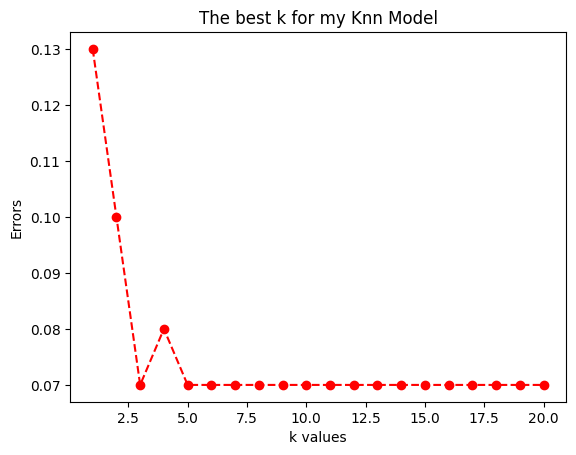

In [17]:
plt.plot(k_values, errors, color = "red", marker = "o", linestyle = "dashed")
plt.xlabel("k values")
plt.ylabel("Errors")
plt.title("The best k for my Knn Model")
plt.show()

In [18]:
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)

In [19]:
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)


In [20]:
print(accuracy_score(y_test, y_pred))

0.93


In [27]:
df[(df["Age"] > 20) & 
            (df["EstimatedSalary"] > 149000) & 
            (df["Purchased"] == 1)]

,Age,EstimatedSalary,Purchased
7,32,150000,1
211,52,150000,1


In [33]:
## For example i want to know if this customer going to buy the product
## I create a test customer as the new array with age 20 and salary 200000 €

new_customer = pd.DataFrame ([[20, 200000]], columns = ["Age", "EstimatedSalary"]) ## Age = 20, Salary = 200000



In [34]:
new_customer_scaled = scaler.transform(new_customer)

In [35]:
prediction = knn.predict(new_customer_scaled)

if prediction[0] == 1:
    print("This Customer will buy our product")
else:
    print("This Customer will not buy our product")
    

This Customer will buy our product
